In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
import pymatching

In [2]:
#parameters
N =200 # needs to be large
delta = 0.3 # to sqeeeze
epsilon = 0.2 
n = 6 #gkp qubit peaks
noise = 0.1 # for displacement noise
n_trials = 2000 # for monte carlo

sqrt_pi = np.sqrt(np.pi) # to write less later on
sqrt_2 = np.sqrt(2)

def pos_to_alpha(q, p=0): #will correct first for only q  noise 
    return (q + 1j* p) /sqrt_2 #takes values into qutip alpha ranges

def GKP_built(N, delta, epsilon, n):
    #vaccum
    vac = basis(N, 0)

    #squeezing - narrow gauss - stat phys
    r = -np.log(delta) 
    S = squeeze(N, r)
    peak_state = S * vac

    # gkp logical 0
    # = sum k | q = 2k sqrt pi>
    gkp = 0 * peak_state #sets it to zero state rather than 1
    for k in range(-n, n + 1):
        weight = np.exp(-2 * np.pi * epsilon**2 * k**2)
        alpha = pos_to_alpha(2 * k * sqrt_pi)
        D = displace(N, alpha)
        gkp += weight * D * peak_state

    return gkp.unit()

state = GKP_built(N, delta, epsilon, n)

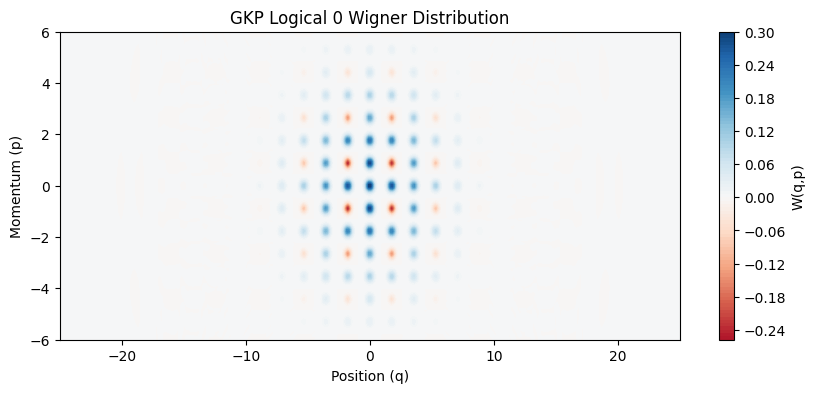

In [5]:
from qutip import wigner

xvec = np.linspace(-25, 25, 400) 
# Momentum (p) envelope is narrower, spanning roughly -6 to 6
yvec = np.linspace(-6, 6, 200)

# 2. Compute the Wigner function (N=200 can take 5-10 seconds to compute)
W = wigner(state, xvec, yvec)

# 3. Plot the grid
fig, ax = plt.subplots(figsize=(10, 4))
contour = ax.contourf(xvec, yvec, W, 100, cmap='RdBu', vmin=-1/np.pi, vmax=1/np.pi)

# 4. Formatting
ax.set_xlabel('Position (q)')
ax.set_ylabel('Momentum (p)')
ax.set_title('GKP Logical 0 Wigner Distribution')
plt.colorbar(contour, label='W(q,p)')
plt.show()

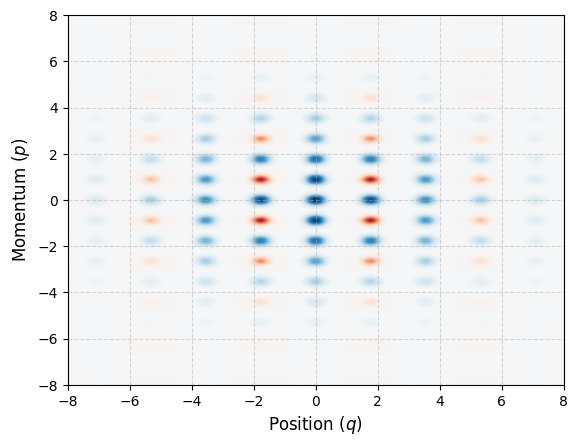

In [7]:
# 1. Define your axes ranges (e.g., from -8 to 8)
xvec = np.linspace(-8, 8, 200)
yvec = np.linspace(-8, 8, 200)  # Add a y-vector for the momentum axis

# 2. Generate the plot, passing both vectors
fig, ax = qutip.plot_wigner(state, xvec=xvec, yvec=yvec)

ax.set_xlabel(r"Position ($q$)", fontsize=12)
ax.set_ylabel(r"Momentum ($p$)", fontsize=12)

# 4. Optional: Adjust ticks or gridlines if you want specific spacing
ax.set_xticks(np.arange(-8, 9, 2))
ax.set_yticks(np.arange(-8, 9, 2))
ax.grid(True, linestyle='--', alpha=0.5)

# 5. Show the plot
plt.show()

In [8]:
import numpy as np
import qutip
import matplotlib.pyplot as plt

# --- Your modified class or a quick script implementation ---
def build_gkp_state(logical_state=0):
    vac = qutip.basis(N, 0)
    r = -np.log(delta)
    S = qutip.squeeze(N, r)
    peak_state = S * vac

    k_vals = np.arange(-n, n + 1)
    weights = np.exp(-2 * np.pi * epsilon**2 * k_vals**2)

    # Shift positions by sqrt_pi if logical_state is 1
    shift = sqrt_pi if logical_state == 1 else 0
    positions = 2 * k_vals * sqrt_pi + shift
    
    alphas = (positions + 1j * 0) / sqrt_2

    displaced_states = np.hstack([
        (qutip.displace(N, alpha) * peak_state).unit().full() 
        for alpha in alphas
    ])

    state_array = (displaced_states @ weights).reshape(-1, 1)
    gkp = qutip.Qobj(state_array)
    gkp.dims = [[N], [1]]
    return gkp

# Generate both states
state_0 = build_gkp_state(logical_state=0)
state_1 = build_gkp_state(logical_state=1)

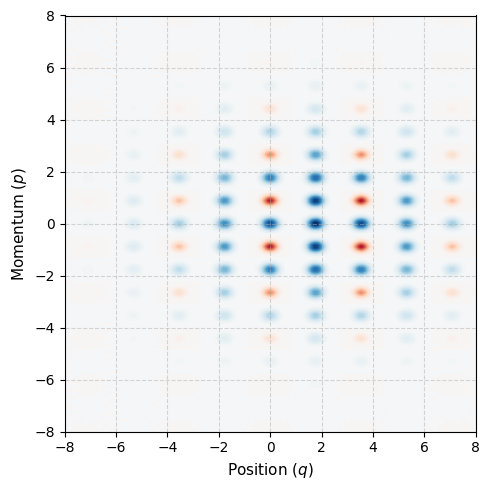

In [12]:
import matplotlib.pyplot as plt

# 1. Generate just the logical 1 state using the shift
state_1 = build_gkp_state(logical_state=1)

# 2. Set up the grid vectors
xvec = np.linspace(-8, 8, 200)
yvec = np.linspace(-8, 8, 200)

# 3. Create a single, column-width figure
fig, ax = plt.subplots(figsize=(5, 5))

# 4. Plot the Wigner function on that axis
qutip.plot_wigner(state_1, xvec=xvec, yvec=yvec, ax=ax)


ax.set_xlabel(r"Position ($q$)", fontsize=11)
ax.set_ylabel(r"Momentum ($p$)", fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)

# Clean up layout and display
plt.tight_layout()
plt.show()

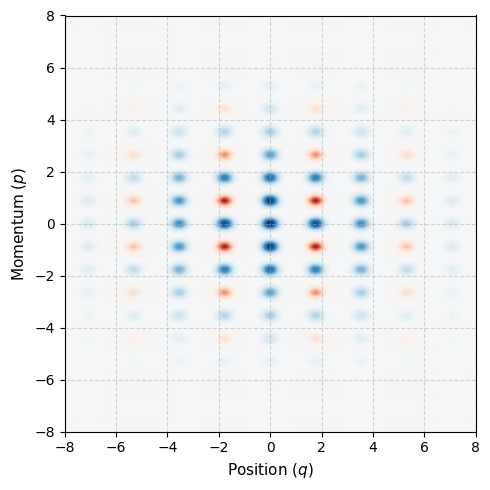

In [13]:
state_0 = build_gkp_state(logical_state=0)

# 2. Set up the grid vectors
xvec = np.linspace(-8, 8, 200)
yvec = np.linspace(-8, 8, 200)

# 3. Create a single, column-width figure
fig, ax = plt.subplots(figsize=(5, 5))

# 4. Plot the Wigner function on that axis
qutip.plot_wigner(state_0, xvec=xvec, yvec=yvec, ax=ax)

# 5. Add clear, publication-ready labels
ax.set_xlabel(r"Position ($q$)", fontsize=11)
ax.set_ylabel(r"Momentum ($p$)", fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()